# mechanism_viewer real-world example

## Horse colic dataset

This notebook applies `mechanism_viewer` to the horse colic dataset. The goal is to explore whether the missing values look consistent with `MCAR`, `MAR`, `MNAR`, or a mixed missingness mechanism.

The dataset has a useful data dictionary, so the analysis uses domain meaning when choosing variables. For example, `pulse`, `rectal_temp`, `packed_cell_volume`, `total_protein`, `abdomo_appearance`, and `abdomo_protein` are clinically meaningful measurements. But `hospital_number` is only an identifier and, thus, it should not be treated as a causal predictor.

> Note: `mechanism_viewer` is purely exploratory. The plots and tests give evidence about missingness, but they can not garantee the true data mechanism.

### 1. Load the dataset

In [1]:
import pandas as pd

df = pd.read_csv("../sample_data/horse/horse.csv")
display(df.head())
print(df.shape)

,surgery,age,hospital_number,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,...,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3,cp_data
0,no,adult,530101,38.5,66.0,28.0,cool,reduced,NaN,more_3_sec,...,45.0,8.4,NaN,NaN,died,no,11300,0,0,no
1,yes,adult,534817,39.2,88.0,20.0,NaN,NaN,pale_cyanotic,less_3_sec,...,50.0,85.0,cloudy,2.0,euthanized,no,2208,0,0,no
2,no,adult,530334,38.3,40.0,24.0,normal,normal,pale_pink,less_3_sec,...,33.0,6.7,NaN,NaN,lived,no,0,0,0,yes
3,yes,young,5290409,39.1,164.0,84.0,cold,normal,dark_cyanotic,more_3_sec,...,48.0,7.2,serosanguious,5.3,died,yes,2208,0,0,yes
4,no,adult,530255,37.3,104.0,35.0,NaN,NaN,dark_cyanotic,more_3_sec,...,74.0,7.4,NaN,NaN,died,no,4300,0,0,no


(299, 28)


This dataset in particular has a lot of columns, 28 in fact, so the analysis must be done carefully to avoid missing any important missingness patterns.

In addition, the dataset contains a mix of continuous and categorical variables.

### 2. Removing columns

For the missingness analysis, the identifiers will be removed, which in this case is the `hospital_number` column.

Furthermore, the given information mentions that `cp_data` is a `variable is of no significance`, thus it will be also removed from the dataset.

In [2]:
df.drop(columns=["hospital_number", "cp_data"], inplace=True)

### 3. Explore the dataset

The code below gives a quick view of the observed distributions before analysing missingness. Continuous variables are shown as histograms, while categorical variables are shown as bar charts.

In [3]:
continuous_columns = ["rectal_temp", "pulse", "respiratory_rate", "nasogastric_reflux_ph",
                        "packed_cell_volume", "total_protein", "abdomo_protein"]

categorical_columns = [ "surgery", "age", "temp_of_extremities", "peripheral_pulse", "mucous_membrane",
    "capillary_refill_time", "pain", "peristalsis", "abdominal_distention",
    "nasogastric_tube", "nasogastric_reflux", "rectal_exam_feces", "abdomen",
    "abdomo_appearance", "outcome", "surgical_lesion", "lesion_1", "lesion_2", "lesion_3"]

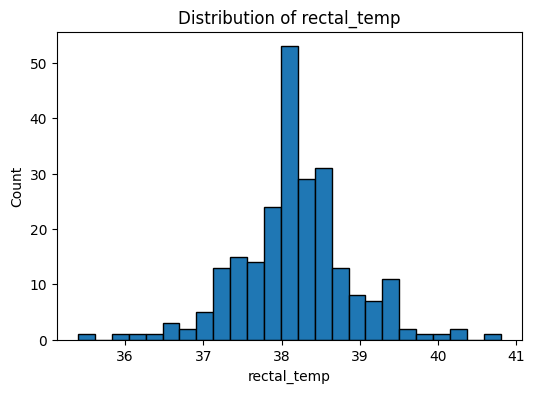

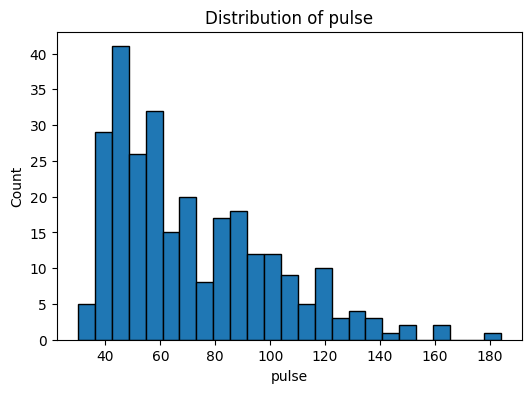

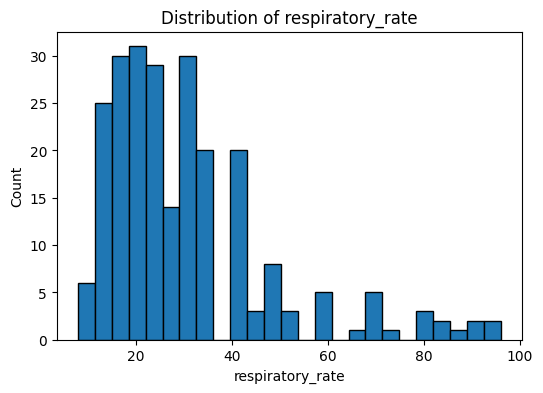

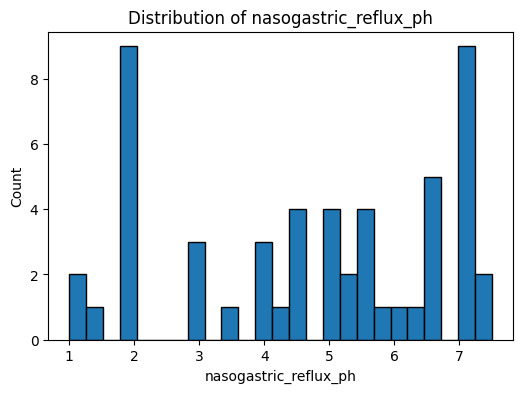

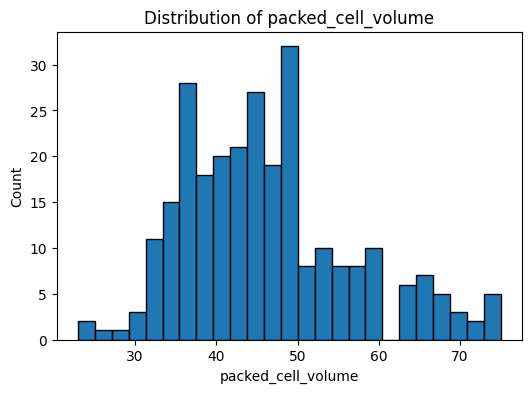

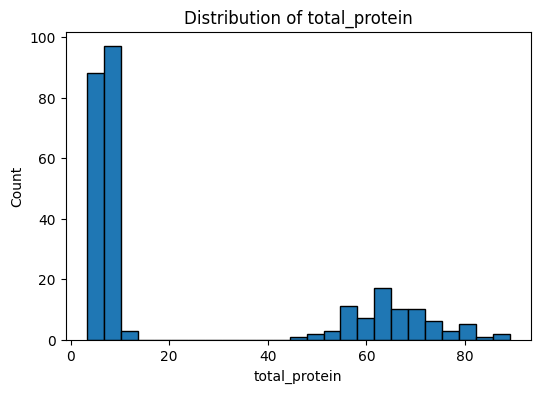

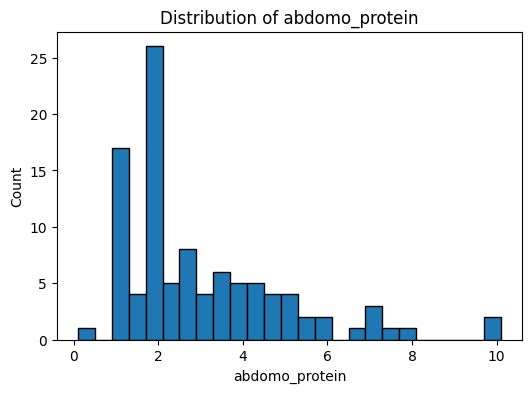

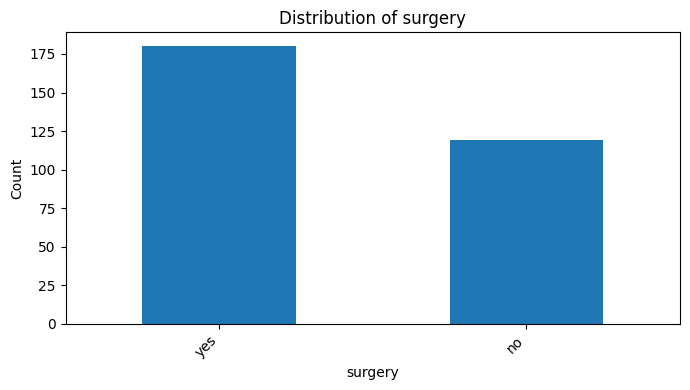

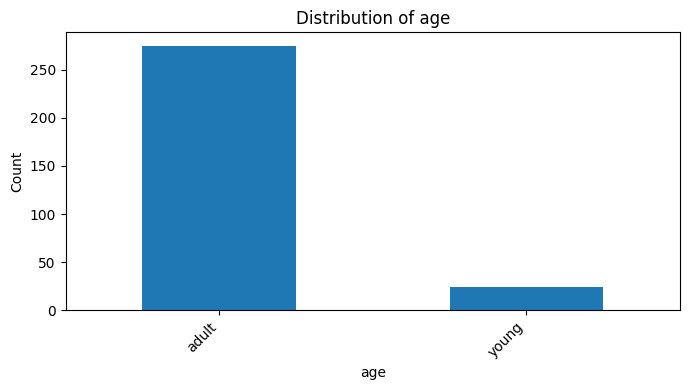

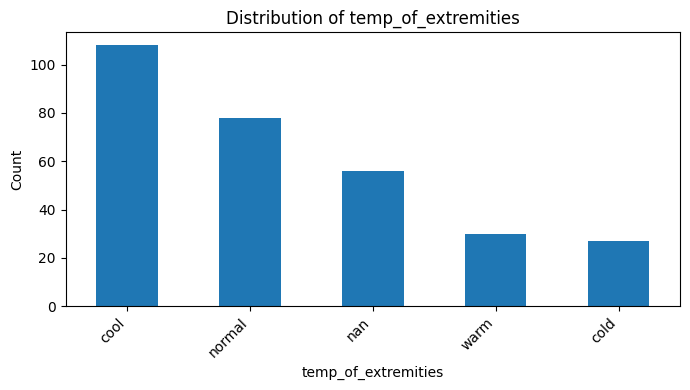

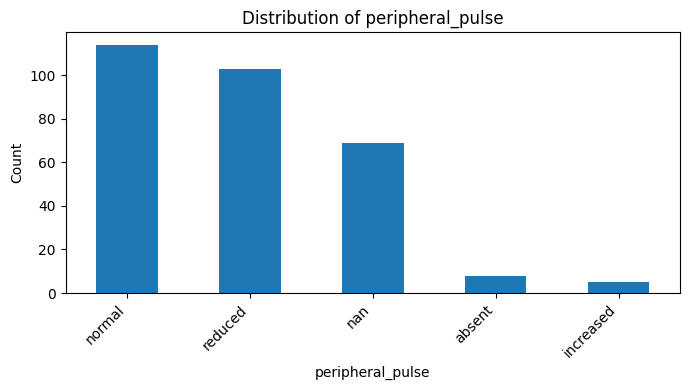

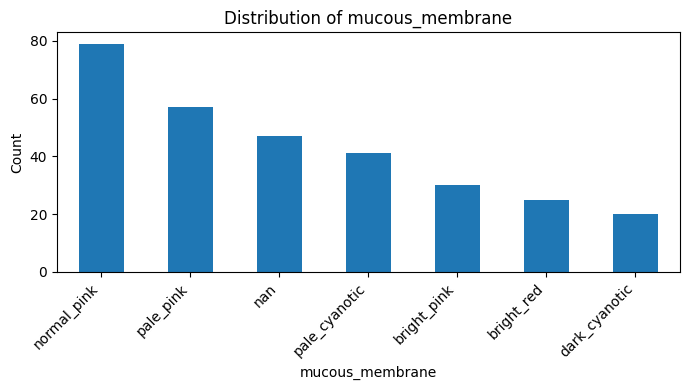

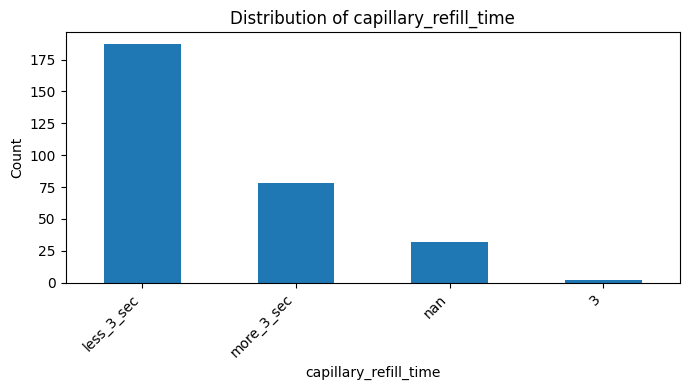

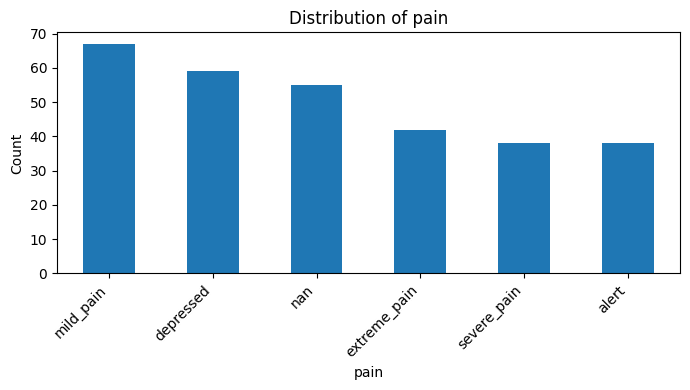

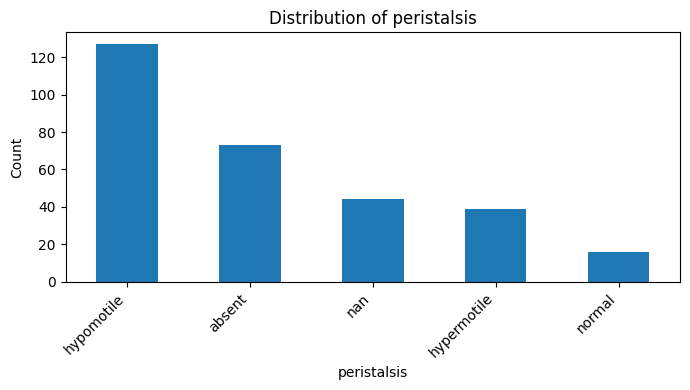

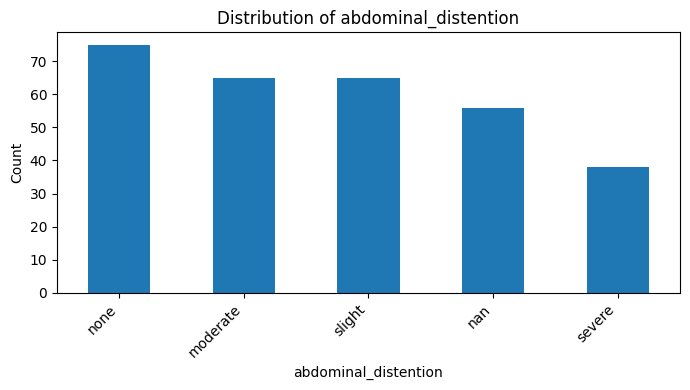

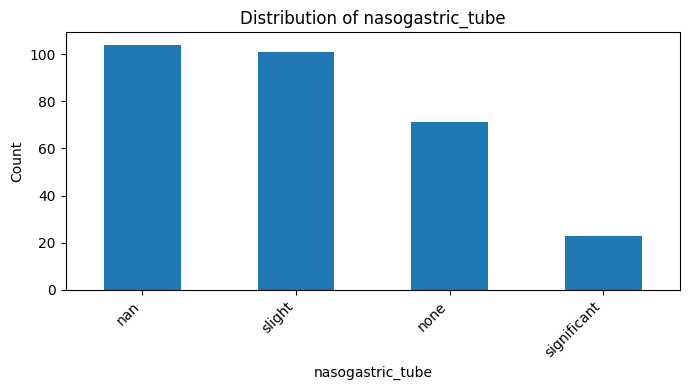

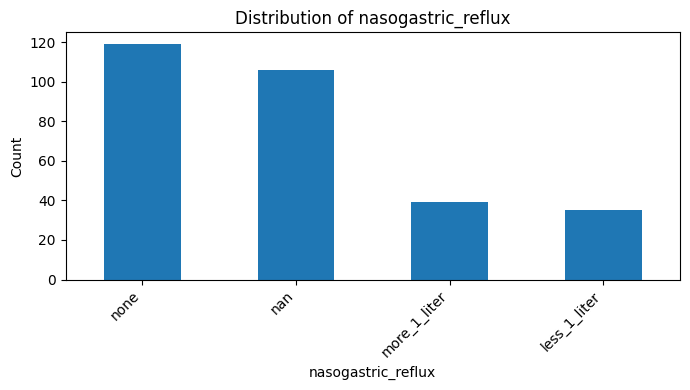

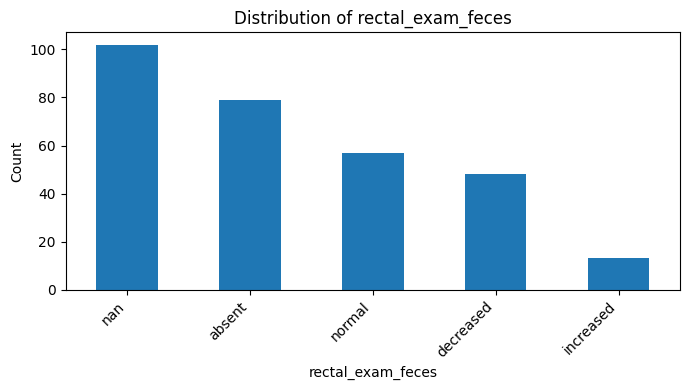

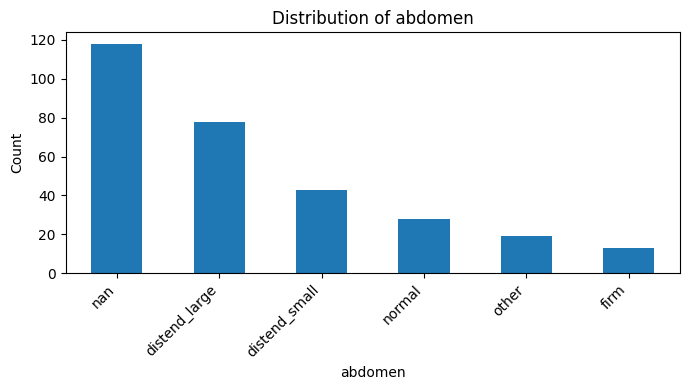

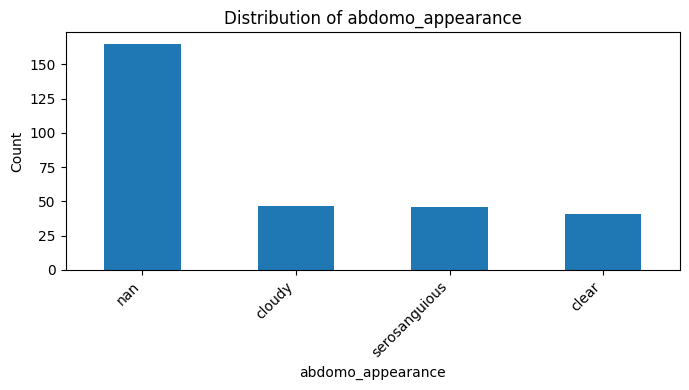

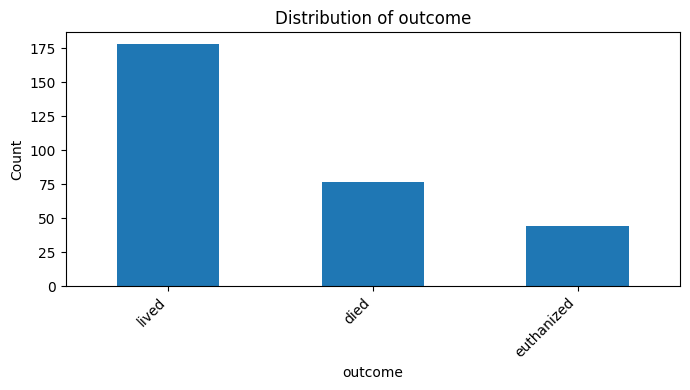

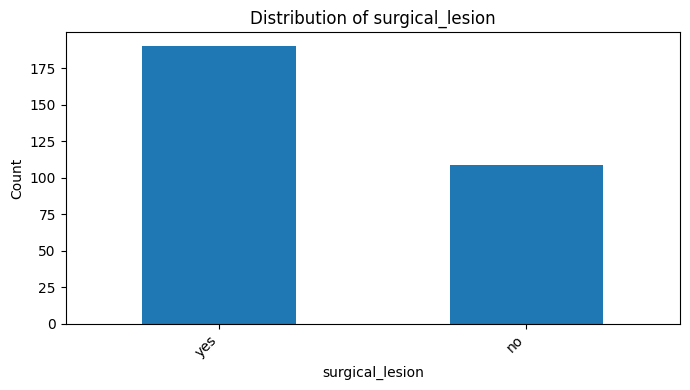

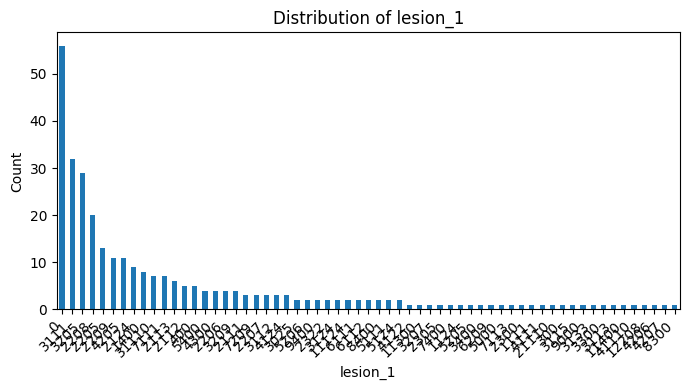

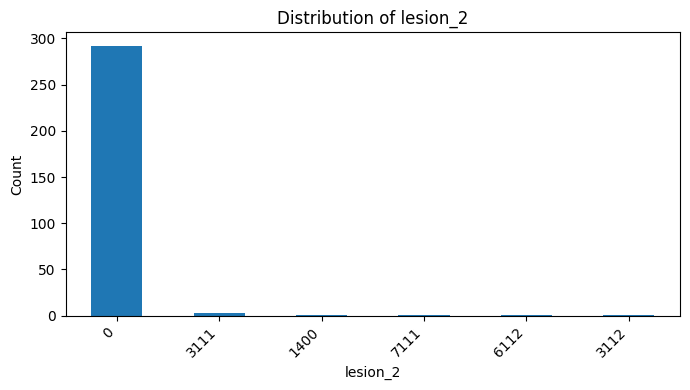

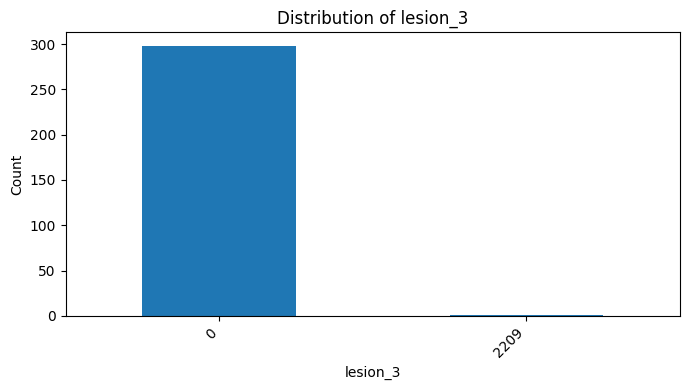

In [4]:
import matplotlib.pyplot as plt

for col in continuous_columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(df[col].dropna(), bins=25, edgecolor="black")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.show()

for col in categorical_columns:
    fig, ax = plt.subplots(figsize=(7, 4))
    df[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Compared to the `diabetes` dataset, this dataset already has the missing values with the correct missing indicators. Therefore, no transformations are necessary.

### 4. Overall missing-rate plot

This is the first `mechanism_viewer` step. It shows which columns deserve the most attention.

C:\Users\Utiizador\Desktop\mestrado1\semestre1\IA_E_SOCIEDADE\individual_assignment\mechanism_viewer\mechanism_viewer\viewer_simple.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig_missing_rate.tight_layout()


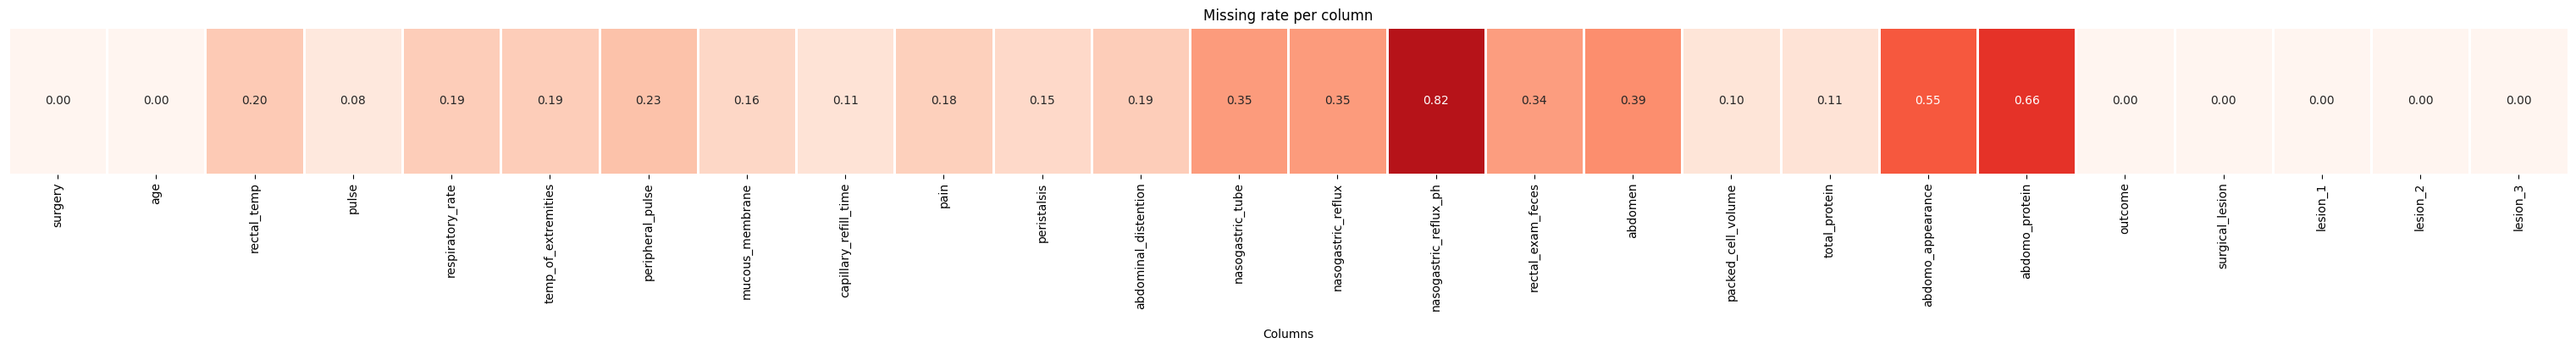

In [31]:
import mechanism_viewer as mv

_, _ = mv.plot_missing_rate(df, display_plot=True)

The most incomplete variables are expected to be the most informative for missingness exploration. In this dataset, the strongest missingness appears in features related to specific examinations: `nasogastric_reflux_ph`, `abdomo_protein`, and `abdomo_appearance`.

Following that, `nasogastric_reflux`, `nasogastric_tube`, `rectal_exam_feces`, `abdomen` have a high similar missing rate. 

This already suggests that the missingness from these features may be due to procedure of the clinic, and not purely random. In other words, additional tests may be performed only when the clinician suspects a more severe or specific condition.

Afterwards, the dataset has a group of features that have a missing rate close to 20%. Those being `rectal_temp`, `respiratory_rate`, `temp_of_extremities`, `peripheral_pulse`, `mucous_membrane`, `pain`, `peristalsis`, and `abdominal_distention`. These features might belong to common examinations for horses that show sickness. As consequence, they are done regularly but not necessary always.

For variables that have a low missing rate, there are: `pulse`, `capillary_refill_time`, `packed_cell_volume`, `total_protein`. It is possible that the results obtained from these columns may be unreliable due to their missing rate.

Finally, the complete columns are `surgery`, `age`, `outcome`, `surgical_lesion`, `lesion_1`, `lesion_2`, `lesion_3`.

Due to the high number of missing columns, it might be harder to fully comprehend the missingness pattern of each column.



### 5. Prepare a numeric dataset

Several `mechanism_viewer` methods, especially Little's MCAR test and MAR detection using accuracy, require numeric data. As a consequence, it was decided to create a numeric dataset, by encoding the non-numeric features. Of course, the encoding does not correlate with the severity scale of feature, unless the variable is truly ordered.

A mapping of the most complex categorical features will be saved, so that the labels can be interpreted later in the analysis.

The original dataset will be kept for readable plots, while `df_num` will be used for numeric methods.

In [6]:
def encode_df(data: pd.DataFrame) -> pd.DataFrame:
    encoded_df = data.copy()

    # Transform binary columns into numeric binary (already indicated in the text file)
    maps = { "surgery": {"no": 0, "yes": 1}, "age": {"adult": 0, "young": 1},
                "surgical_lesion": {"no": 0, "yes": 1},
                "outcome": {"lived": 0, "died": 1, "euthanized": 2}}
    
    for col, col_map in maps.items():
        encoded_df[col] = encoded_df[col].map(col_map)

    # Encode remaining categorical variables as integer category codes.
    remaining_cols = encoded_df.select_dtypes(include="object").columns
    
    category_maps = {}
    for col in remaining_cols:
        categories = sorted(encoded_df[col].dropna().unique())
        category_maps[col] = {value: i + 1 for i, value in enumerate(categories)}
        encoded_df[col] = encoded_df[col].map(category_maps[col])

    return encoded_df, category_maps


df_num, category_maps = encode_df(df)

In [7]:
display(df_num.head())

print("Encoded categorical maps:")
for col, mapping in category_maps.items():
    print(f"{col}: {mapping}")

,surgery,age,rectal_temp,pulse,respiratory_rate,temp_of_extremities,peripheral_pulse,mucous_membrane,capillary_refill_time,pain,...,abdomen,packed_cell_volume,total_protein,abdomo_appearance,abdomo_protein,outcome,surgical_lesion,lesion_1,lesion_2,lesion_3
0,0,0,38.5,66.0,28.0,2.0,4.0,NaN,3.0,3.0,...,1.0,45.0,8.4,NaN,NaN,1,0,11300,0,0
1,1,0,39.2,88.0,20.0,NaN,NaN,5.0,2.0,4.0,...,5.0,50.0,85.0,2.0,2.0,2,0,2208,0,0
2,0,0,38.3,40.0,24.0,3.0,3.0,6.0,2.0,4.0,...,4.0,33.0,6.7,NaN,NaN,0,0,0,0,0
3,1,1,39.1,164.0,84.0,1.0,3.0,3.0,3.0,2.0,...,NaN,48.0,7.2,3.0,5.3,1,1,2208,0,0
4,0,0,37.3,104.0,35.0,NaN,NaN,3.0,3.0,NaN,...,NaN,74.0,7.4,NaN,NaN,1,0,4300,0,0


Encoded categorical maps:
temp_of_extremities: {'cold': 1, 'cool': 2, 'normal': 3, 'warm': 4}
peripheral_pulse: {'absent': 1, 'increased': 2, 'normal': 3, 'reduced': 4}
mucous_membrane: {'bright_pink': 1, 'bright_red': 2, 'dark_cyanotic': 3, 'normal_pink': 4, 'pale_cyanotic': 5, 'pale_pink': 6}
capillary_refill_time: {'3': 1, 'less_3_sec': 2, 'more_3_sec': 3}
pain: {'alert': 1, 'depressed': 2, 'extreme_pain': 3, 'mild_pain': 4, 'severe_pain': 5}
peristalsis: {'absent': 1, 'hypermotile': 2, 'hypomotile': 3, 'normal': 4}
abdominal_distention: {'moderate': 1, 'none': 2, 'severe': 3, 'slight': 4}
nasogastric_tube: {'none': 1, 'significant': 2, 'slight': 3}
nasogastric_reflux: {'less_1_liter': 1, 'more_1_liter': 2, 'none': 3}
rectal_exam_feces: {'absent': 1, 'decreased': 2, 'increased': 3, 'normal': 4}
abdomen: {'distend_large': 1, 'distend_small': 2, 'firm': 3, 'normal': 4, 'other': 5}
abdomo_appearance: {'clear': 1, 'cloudy': 2, 'serosanguious': 3}


### 6. Global MCAR test

The global Little's MCAR test checks whether the overall missingness pattern is consistent with MCAR.

In [8]:
p_value = mv.little_mcar_test(df_num)
print(mv.interpret_mcar_p_value(p_value))


Obtained p_value is 0.0.

Interpretation: Reject the null hypothesis. Data is not MCAR (likely MAR or MNAR)


The result mentions the rejection of the null hypothesis. When this occurs, it typically is due to the presence of at least one variable that does not follow an MCAR mechanism and is instead likely to have MAR or MNAR.

The next step is to inspect which columns contribute most to that signal.

### 7. Pairwise MCAR checks

Pairwise checks are useful because the global test may reject MCAR without showing which variables drive the result.

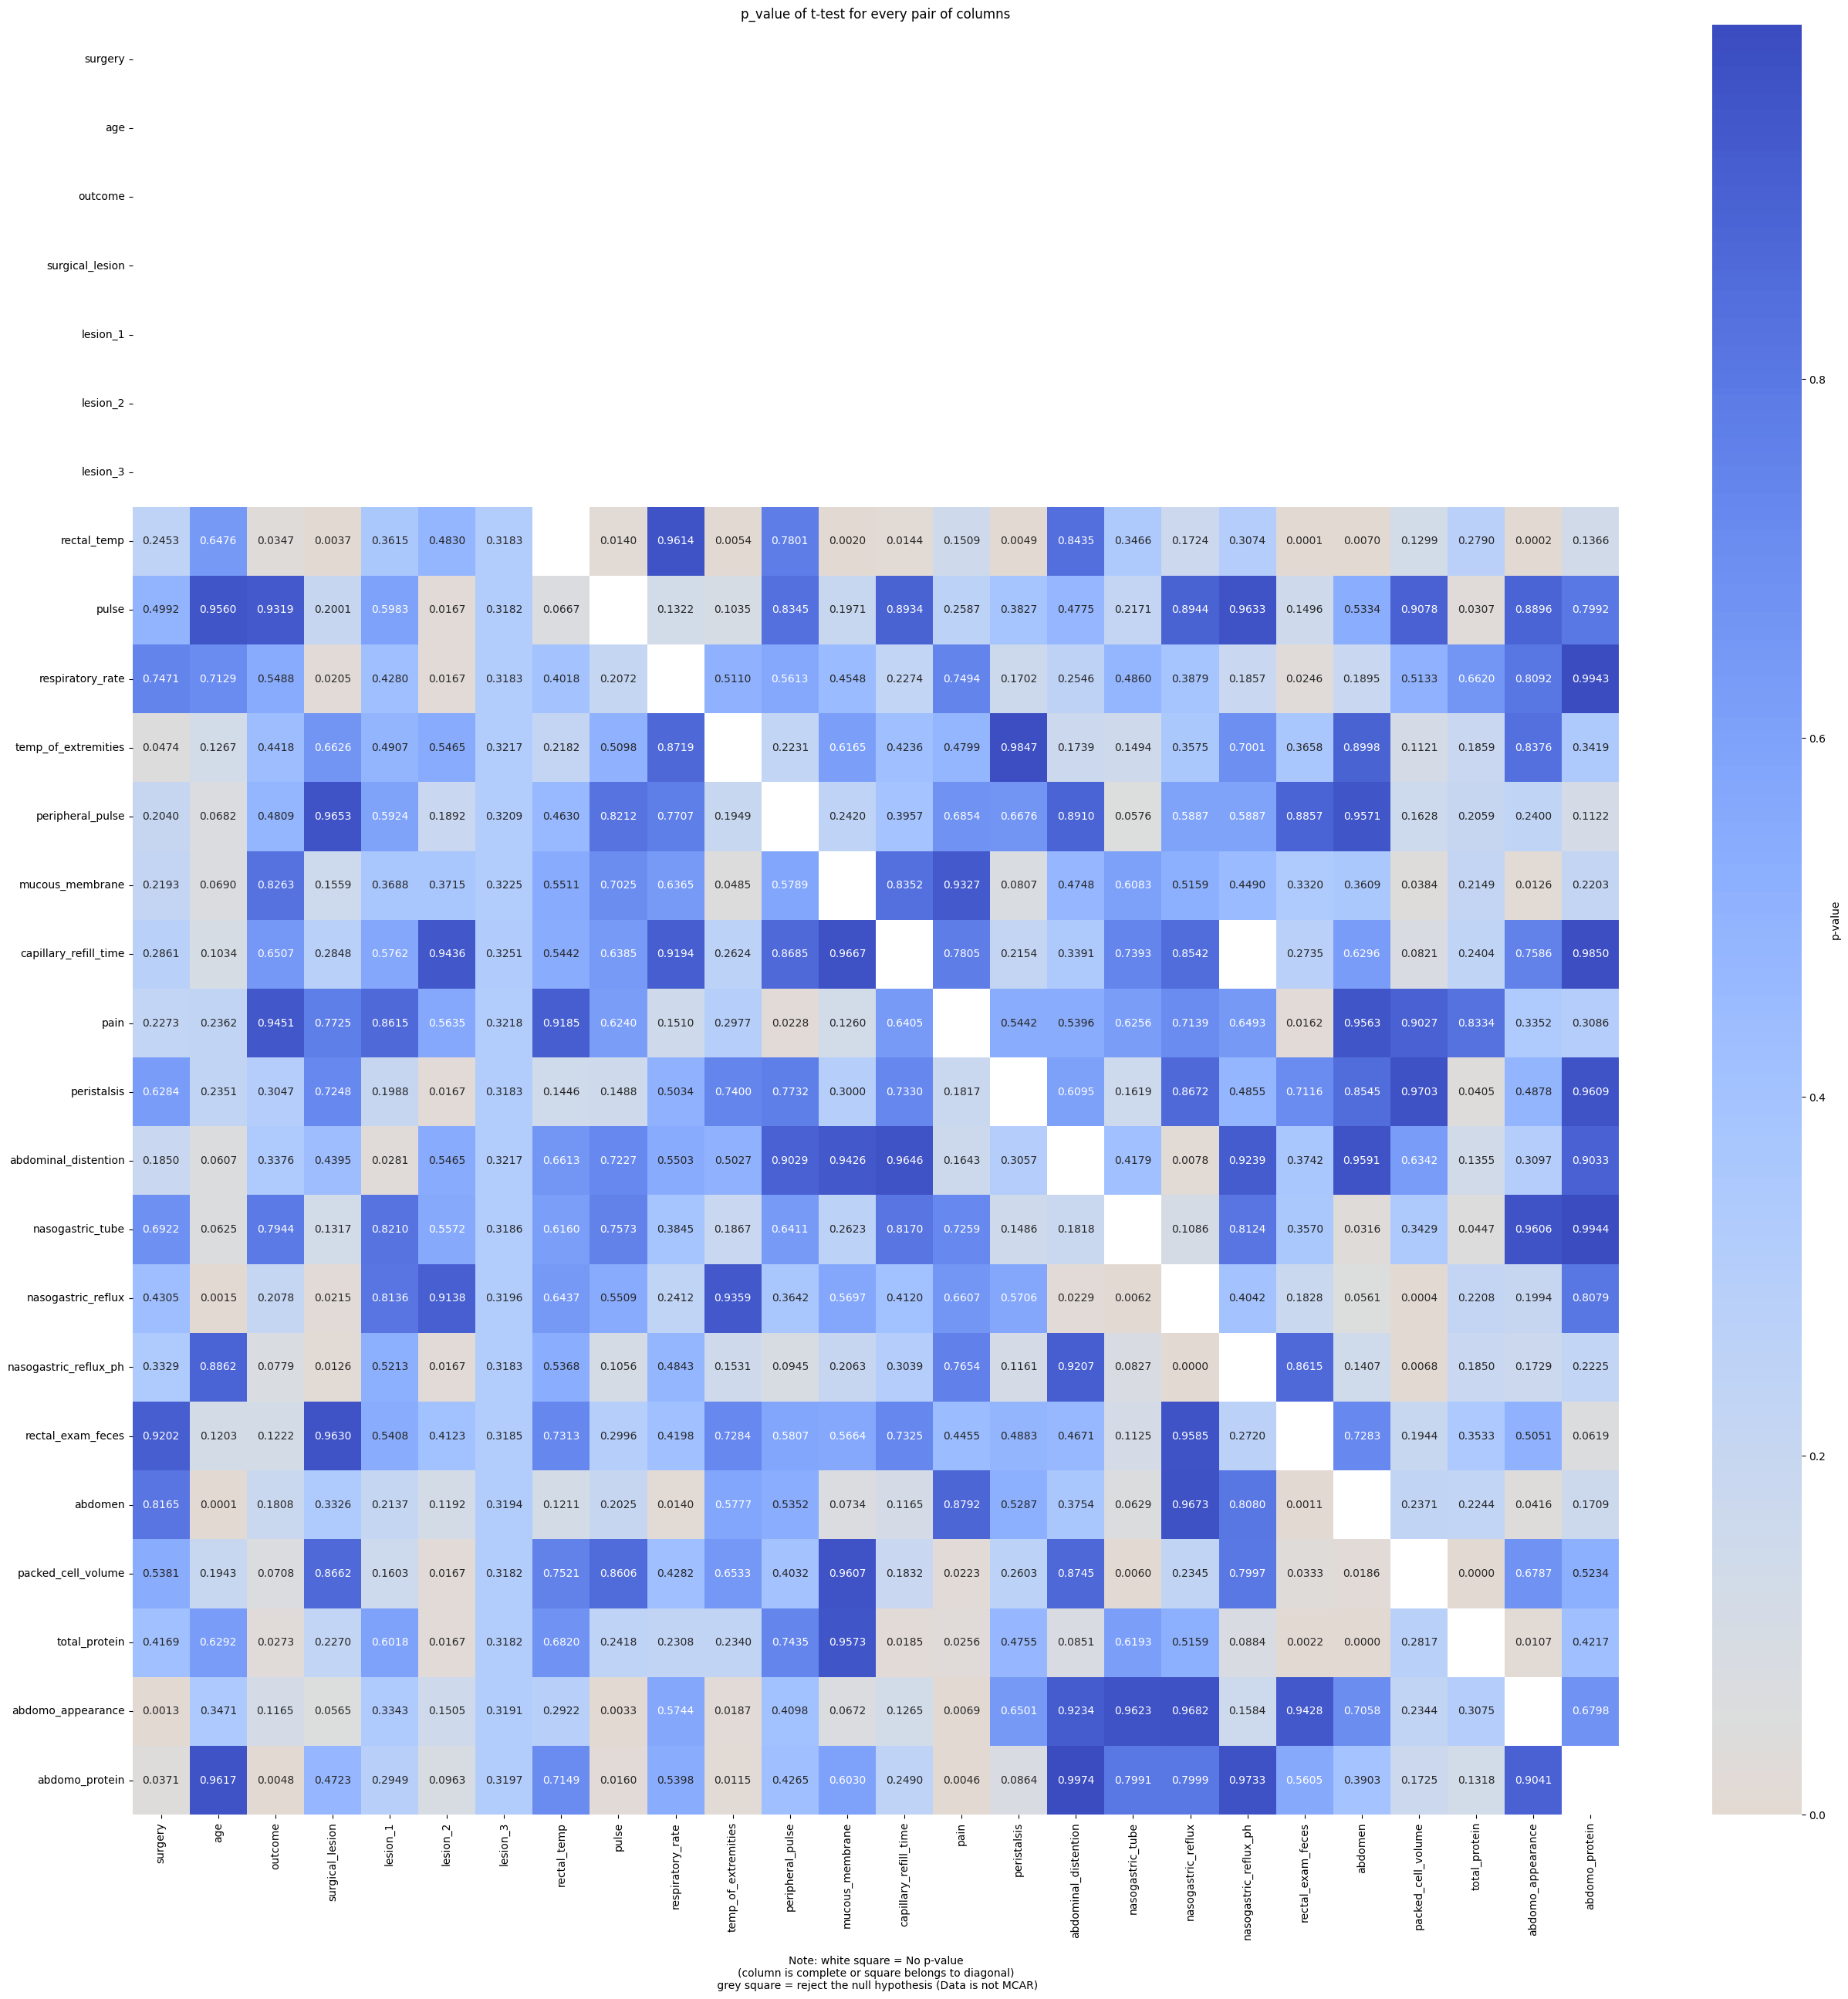

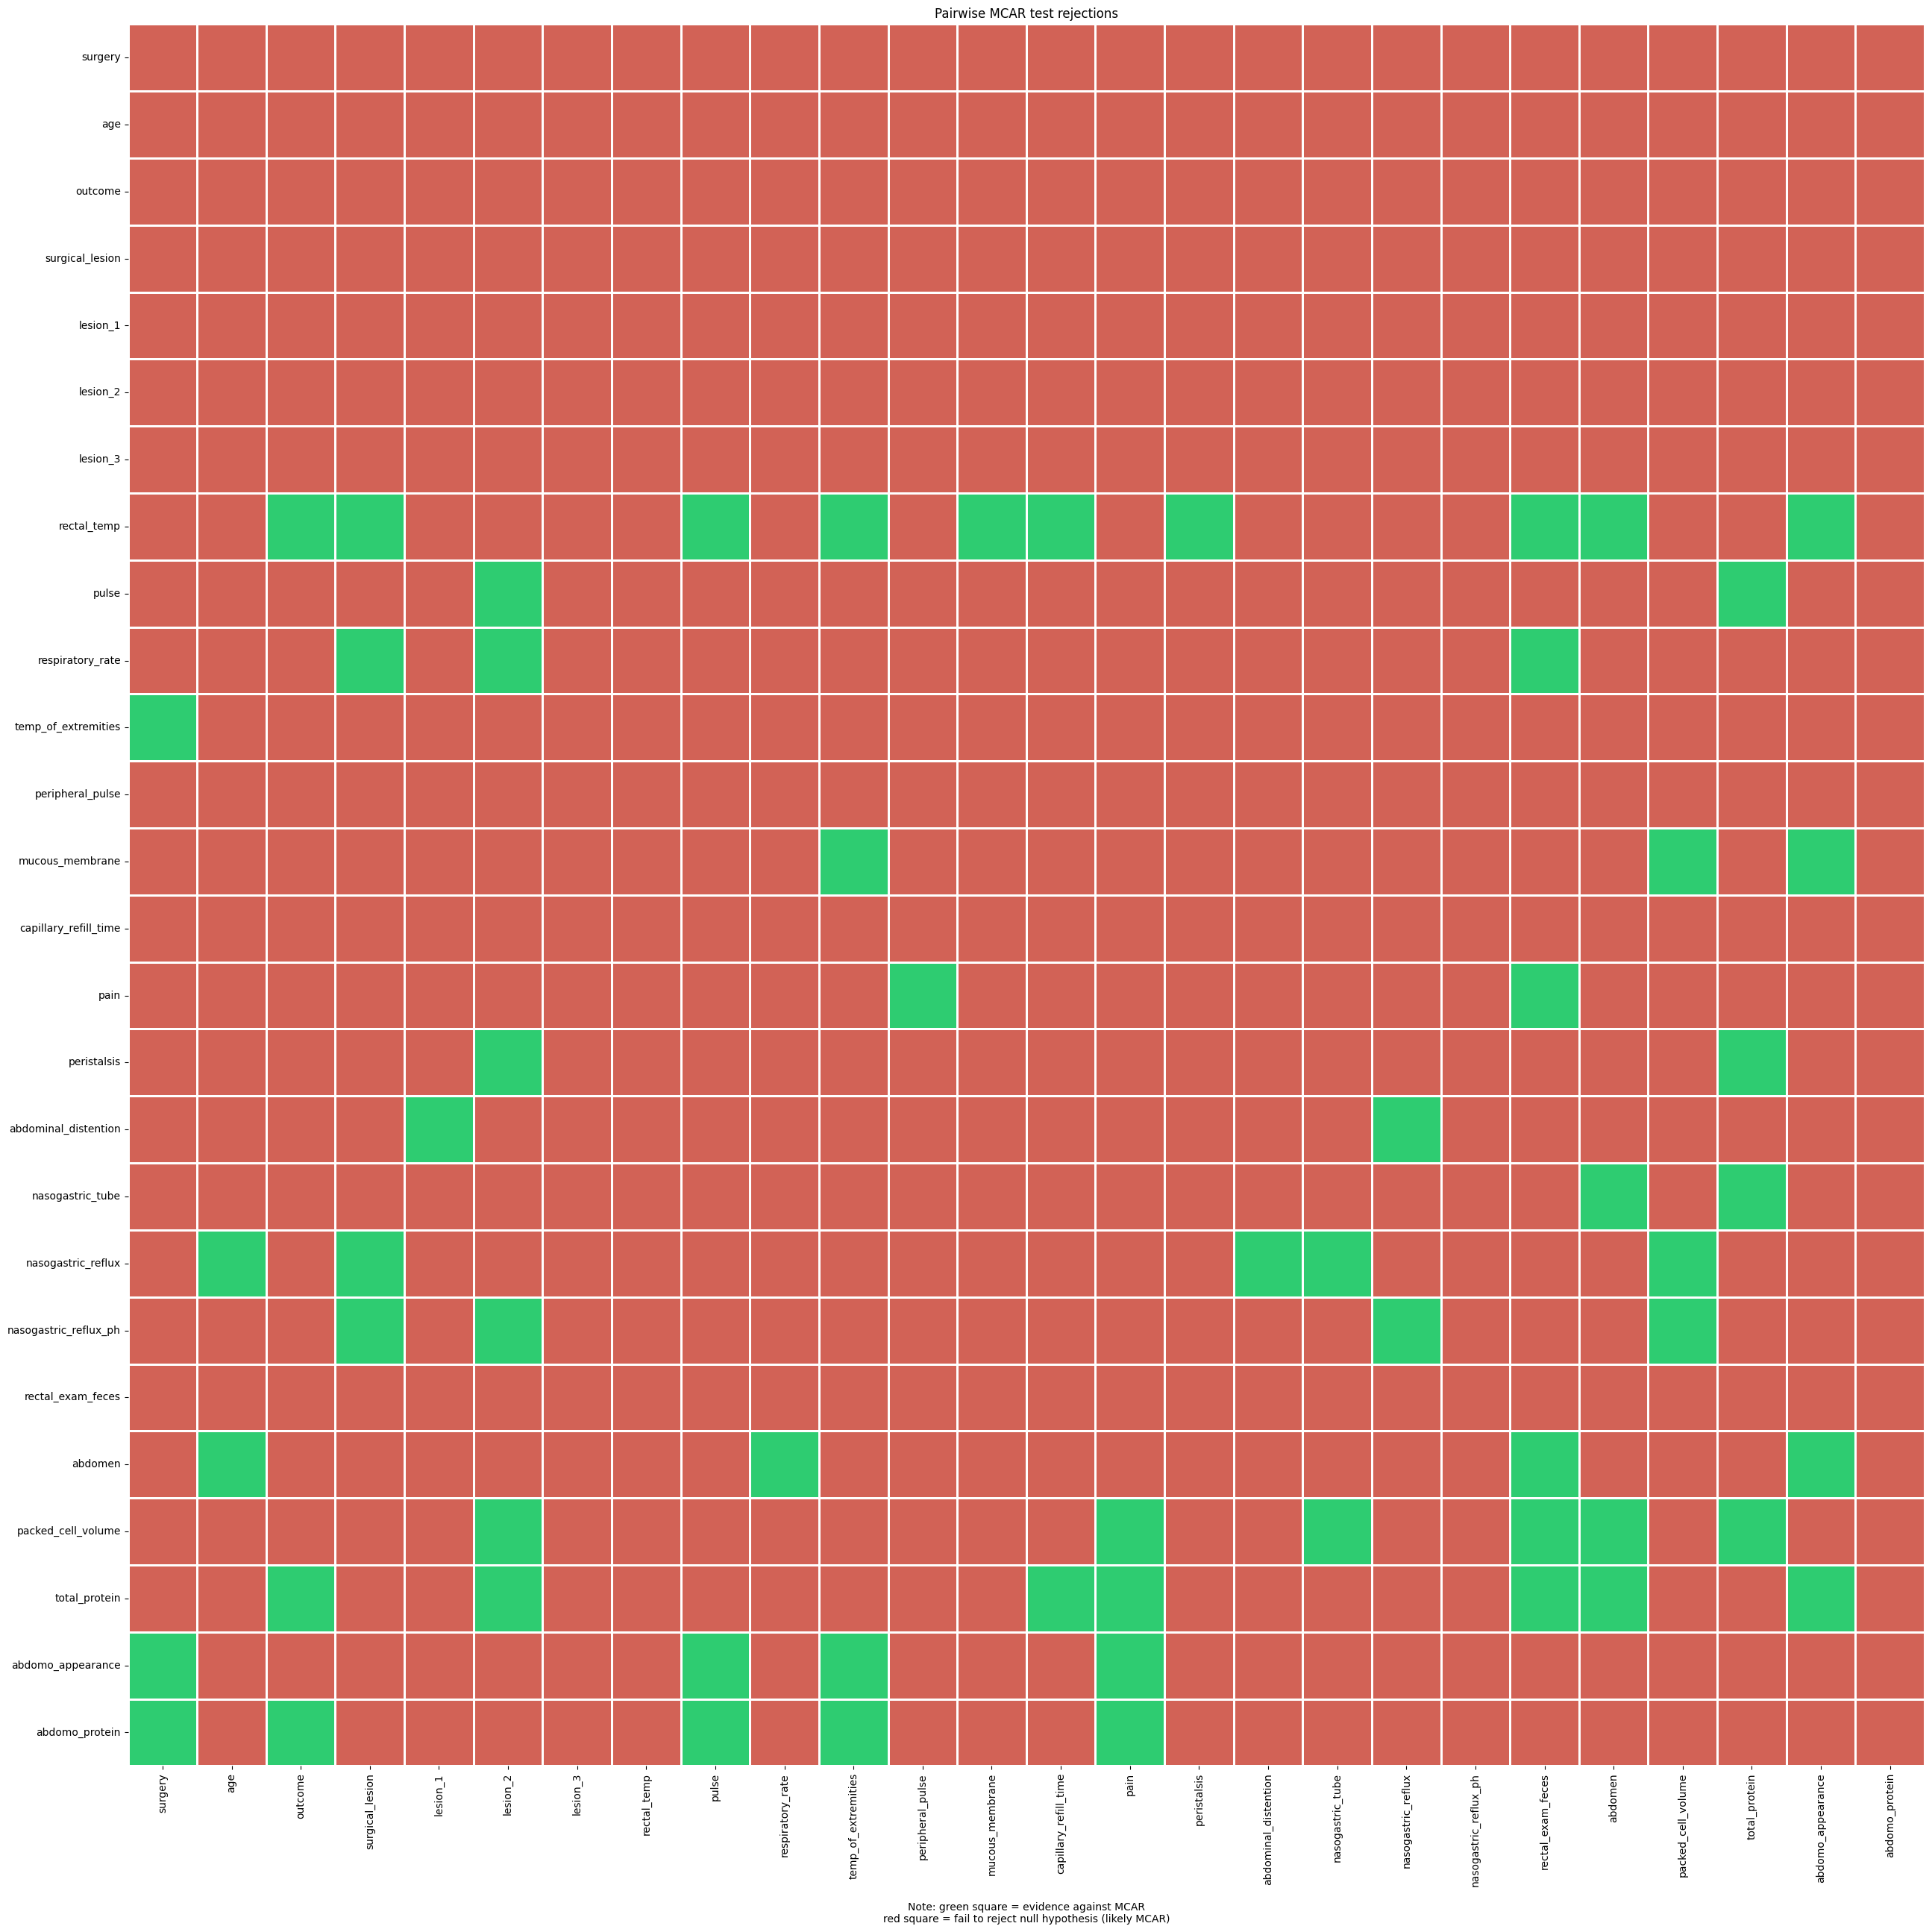

In [9]:
pvalue_matrix = mv.little_mcar_pairwise(df_num)
_, _, _, _ = mv.plot_mcar_pairwise(pvalue_matrix, alpha=0.05, display_plot=True)

These were the missing columns obtained previously:

- High missing rate: `nasogastric_reflux_ph`, `abdomo_protein`, `abdomo_appearance`.

- Medium missing rate: `nasogastric_reflux`, `nasogastric_tube`, `rectal_exam_feces`, `abdomen`.

- Low missing rate: `rectal_temp`, `respiratory_rate`, `temp_of_extremities`, `peripheral_pulse`, `mucous_membrane`, `pain`, `peristalsis`, `abdominal_distention`.

- Very low missing rate: `pulse`, `capillary_refill_time`, `packed_cell_volume`, `total_protein`.


From those missing columns, only the following ones were displayed as likely having MCAR pattern:

- High missing rate: None.

- Medium missing rate: `rectal_exam_feces`.

- Low missing rate: `peripheral_pulse`.

- Very low missing rate: `capillary_refill_time`

The rest have displayed a non-MCAR missing pattern.

The variables that most contributed to generate missing dependency can be visualized in the next table.

In [10]:
reject_counts = (pvalue_matrix <= 0.05).sum().sort_values(ascending=False)
display(reject_counts.to_frame("dependencies_generated").head(15))

,dependencies_generated
lesion_2,6
rectal_exam_feces,6
pain,4
abdomen,4
abdomo_appearance,4
total_protein,4
temp_of_extremities,4
surgical_lesion,4
outcome,3
surgery,3


Somehow `lesion_2` and `rectal_exam_feces` have the highest number of possible dependencies created.

Meanwhile, `pain`, `abdomen`, `abdomo_appearance`, `total_protein`, `temp_of_extremities`, `surgical_lesion`, `outcome`, `surgery`, `packed_cell_volume` and `pulse` have a moderate number.

Lastly, `capillary_refill_time`, `nasogastric_tube`, and `age` have only 2 possible dependencies created.

From this analysis, it is possible to remove `peripheral_pulse`, since it does not generate any missingness dependency and does not appear to have a non‑MCAR mechanism. In other words, it does not provide enough information to contribute meaningfully to the analysis.

On the other hand, `rectal_exam_feces` and `capillary_refill_time` show MCAR behavior in the plots, but have a considerable number of columns that may depend on them, so they remain in the analysis.

Now, for the actual features that have possible MAR mechanism, with the group of features that possibly generate the missingness:

- ``rectal_temp``: ``outcome``, ``surgical_lesion``, ``pulse``, ``temp_of_extremities``, ``mucous_membrane``, ````capillary_refill_time````, ``peristalsis``, ``rectal_exam_feces``, ``abdomen``, ``abdomo_appearance``

- ``pulse``: ``lesion_2``, ``total_protein``
- ``respiratory_rate``: ``surgical_lesion``, ``lesion_2``, ``rectal_exam_feces``
- ``temp_of_extremities``: ``surgery``
- ``mucous_membrane``: ``temp_of_extremities``, ``packed_cell_volume``, ``abdomo_appearance``
- ``pain``: ``peripheral_pulse``, ``rectal_exam_feces``
- ``peristalsis``: ``lesion_2``, ``total_protein``
- ``abdominal_distention``: ``lesion_1``, ``nasogastric_reflux``
- ````nasogastric_tube````: ``abdomen``, ``total_protein``
- ``nasogastric_reflux``: ``age``, ``surgical_lesion``, ``abdominal_distention``, ````nasogastric_tube````, ``packed_cell_volume``
- ``nasogastric_reflux_ph``: ``surgical_lesion``, ````lesion_2````, ``nasogastric_reflux``, ``packed_cell_volume``
- ``abdomen``: ``age``, ``respiratory_rate``, ``rectal_exam_feces``, ``abdomo_appearance``
- ``packed_cell_volume``: ``lesion_2``, ``pain``, ``nasogastric_tube``, ``rectal_exam_feces``, ``abdomen``, ``total_protein``
- ``total_protein``: ``outcome``, ````lesion_2````, ``capillary_refill_time``, ``pain``, ``rectal_exam_feces``, ``abdomen``, ``abdomo_appearance``
- ``abdomo_appearance``: ``surgery``, ``pulse``, ``temp_of_extremities``, ``pain``
- ``abdomo_protein``: ``surgery``, ``outcome``, ````pulse````, ``temp_of_extremities``, ``pain``

In [11]:
mar_possible_df = {
    "rectal_temp": [
        "rectal_temp", "outcome", "surgical_lesion", "pulse", "temp_of_extremities",
        "mucous_membrane", "capillary_refill_time", "peristalsis",
        "rectal_exam_feces", "abdomen", "abdomo_appearance"
    ],
    "pulse": ["pulse", "lesion_2", "total_protein"],
    "respiratory_rate": ["respiratory_rate", "surgical_lesion", "lesion_2", "rectal_exam_feces"],
    "temp_of_extremities": ["temp_of_extremities", "surgery"],
    "mucous_membrane": ["mucous_membrane", "temp_of_extremities", "packed_cell_volume", "abdomo_appearance"],
    "pain": ["pain", "peripheral_pulse", "rectal_exam_feces"],
    "peristalsis": ["peristalsis", "lesion_2", "total_protein"],
    "abdominal_distention": ["abdominal_distention", "lesion_1", "nasogastric_reflux"],
    "nasogastric_tube": ["nasogastric_tube", "abdomen", "total_protein"],
    "nasogastric_reflux": [
        "nasogastric_reflux", "age", "surgical_lesion", "abdominal_distention",
        "nasogastric_tube", "packed_cell_volume"
    ],
    "nasogastric_reflux_ph": [
        "nasogastric_reflux_ph", "surgical_lesion", "lesion_2",
        "nasogastric_reflux", "packed_cell_volume"
    ],
    "abdomen": ["abdomen", "age", "respiratory_rate", "rectal_exam_feces", "abdomo_appearance"],
    "packed_cell_volume": [
        "packed_cell_volume", "lesion_2", "pain", "nasogastric_tube",
        "rectal_exam_feces", "abdomen", "total_protein"
    ],
    "total_protein": [
        "total_protein", "outcome", "lesion_2", "capillary_refill_time",
        "pain", "rectal_exam_feces", "abdomen", "abdomo_appearance"
    ],
    "abdomo_appearance": ["abdomo_appearance", "surgery", "pulse", "temp_of_extremities", "pain"],
    "abdomo_protein": ["abdomo_protein", "surgery", "outcome", "pulse", "temp_of_extremities", "pain"]
}

### 8. Row-level missingness patterns

Since there are still lots of possible non-MCAR columns, it is important to understand which variables dependencies are connected to which group of variables, apart from their missing rate. Therefore, this plot checks whether several variables are missing in the same rows.

Besides, understanding how the row missingness behaves, helps explain which variables come from related clinical procedures.

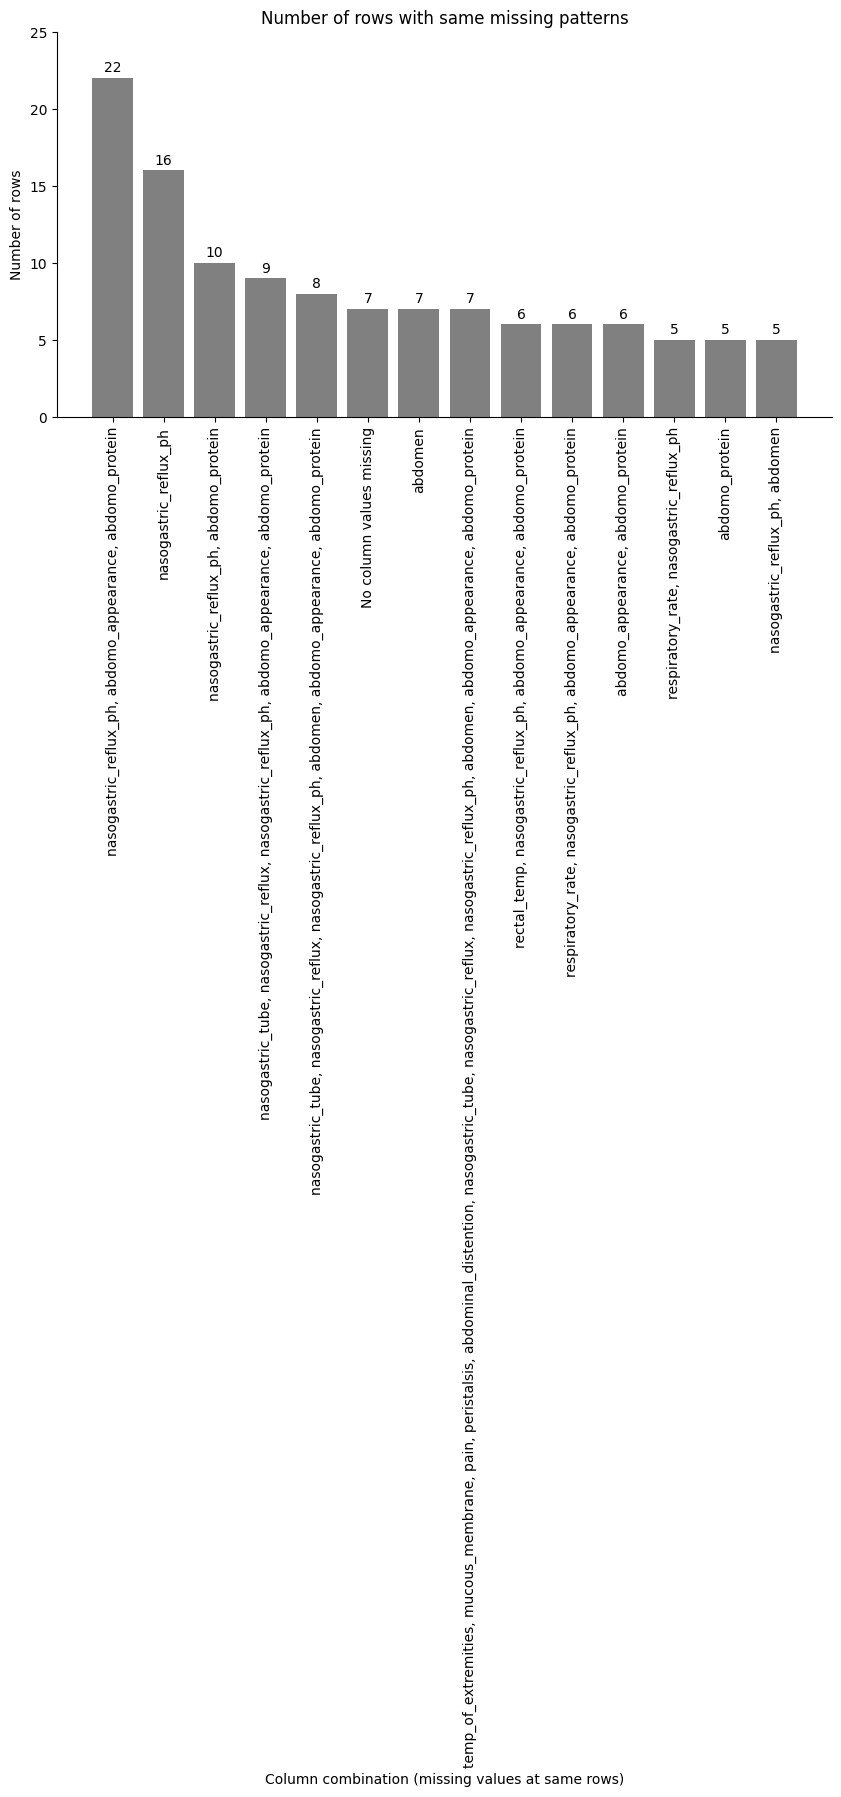

In [12]:
keys = [ "rectal_temp", "pulse", "respiratory_rate", "temp_of_extremities", "mucous_membrane", "pain", "peristalsis", "abdominal_distention",
         "nasogastric_tube", "nasogastric_reflux", "nasogastric_reflux_ph", "abdomen", "packed_cell_volume", "total_protein", "abdomo_appearance", 
         "abdomo_protein"]

fig_similar_miss, ax_similar_miss = mv.rows_with_similar_missing(
    df[keys],
    min_rows_display=5,
    display_plot=True,
)

This missingness plot shows that missing values cluster in clinically related features, rather than being randomly scattered across the dataset.

The most common pattern is the simultaneous missingness of ``nasogastric_reflux_ph``, ``abdomo_protein``, and ``abdomo_appearance``, affecting 22 rows. ``nasogastric_reflux_ph`` also appears alone as a frequent missing column, affecting 16 rows, due to its high missing rate.

In addition, several repeated patterns involve features that have `nasogastric` or `abdom` on its name.

This confirms the hypothesis of the missingness being tied to specific clinical procedures. As a result, the data are unlikely to be purely MCAR.

It is also possible to see a combination of features that appear together with the cluster of `nasogastric`-`abdom`. These are ``temp_of_extremities``, ``mucous_membrane``, ``pain``, and ``peristalsis``. They are missing together in 7 rows.

In the oposite way, ``rectal_temp`` and ``respiratory_rate`` do not appear necessarily together, although they might have features that contribute for both missingness patterns.


### 9. Overall missingness correlation heatmaps

These plots show whether missing columns have their missingness correlated with each other. This can reveal deeper clusters that might be harder to understand with only observing the number of missing rows.

Naturally, the smaller number of total rows may limit the reliability of the observed relationships.

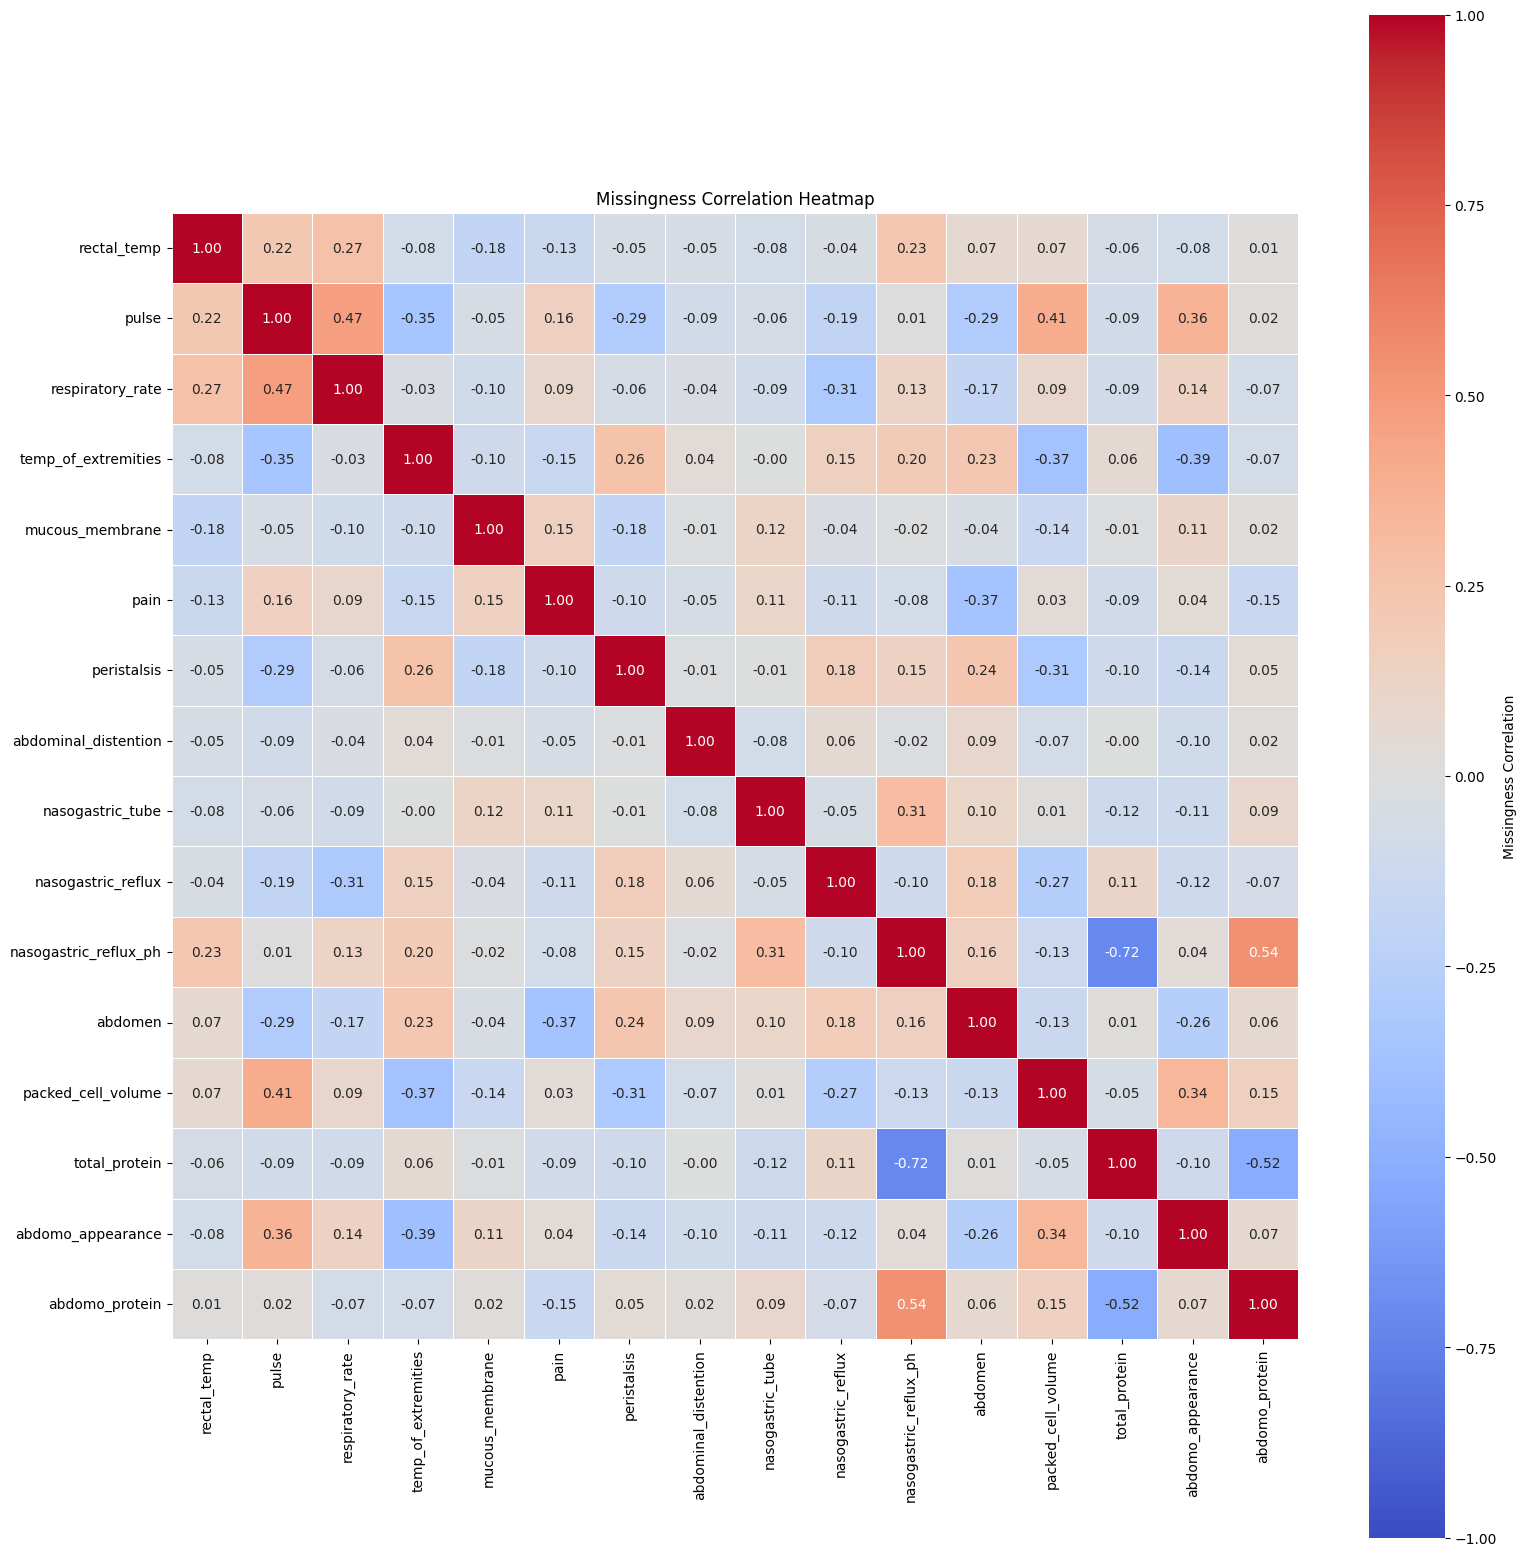

In [13]:
_, _ = mv.missing_columns_correlation(df_num[keys], display_plot=True)

As expected, missingness in ````nasogastric_reflux_ph```` and ````abdomo_protein```` is positively correlated, suggesting that these features are often absent together. In contrast, their missingness is negatively correlated with ````total_protein````, suggesting a different recording pattern for blood protein measurements compared with abdominal/reflux measurements.

The missingness of ``pulse``, ``capillary_refill_time``, and ``packed_cell_volume`` is also moderately correlated, indicating a second group of variables with shared missingness behaviour. This group affects the missingness of other features similarly, with the exception of ````respiratory_rate````, where ``pulse`` has a moderate positive missingness correlation, suggesting that basic vital variables may be omitted together in some records. Interestingly, ``abdomo_appearance`` is positively associated with missingness in this group, especially with ``pulse`` and ``packed_cell_volume``. In contrast, ``temp_of_extremities`` is totally the oposite: moderate negative association between ``abdomo_appearance``, ``pulse`` and ``packed_cell_volume``. It does seem that 

In this plot, it is confirmed that ``rectal_temp`` and ``respiratory_rate`` do not necessarily appear together. For example, correlation between these two is 0.27, and correlation between ``rectal_temp`` and ``pulse`` is only 0.22. These are positive values, but not very strong. So the features have some shared missingness, probably because they are all basic examination variables, but they are not part of one strict missingness block.

Finally, ``pain`` shows a notable negative correlation with ``abdomen``, suggesting that ``pain`` was often still recorded even when detailed abdominal findings were missing.

### 10. Individual missingness correlation heatmaps

Using a heatmap to understand missingness patterns can be difficult, especially when the number of variables at play is large. Therefore, individual heatmaps bring an advantage, by showing whether the missingness of an individual missing is strongly affected by certain features. 

For this section, the heatmaps will display the correlation between the missing columns that rejected an MCAR pattern, and the features that may have contributed to their missingness.


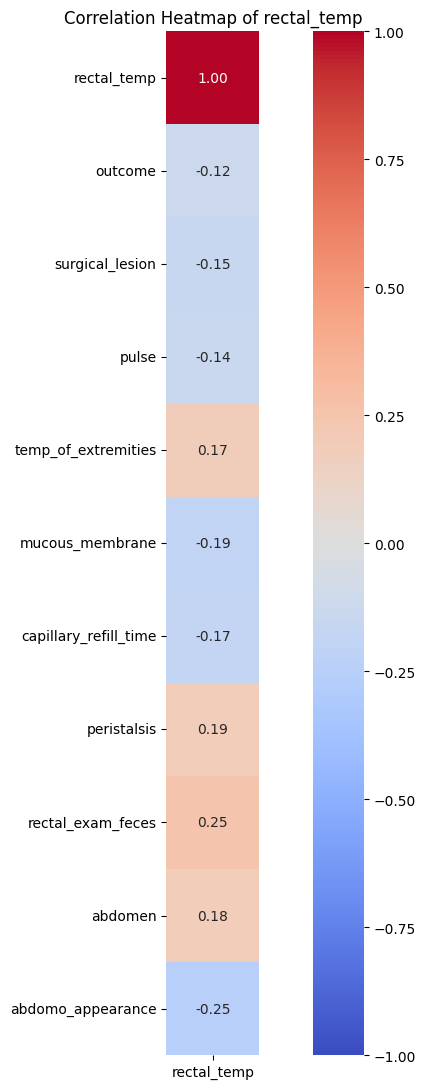

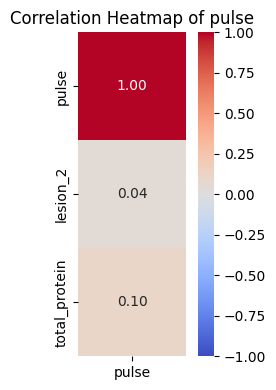

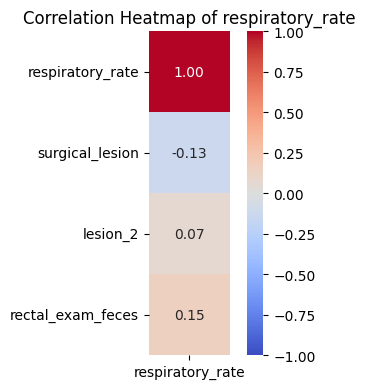

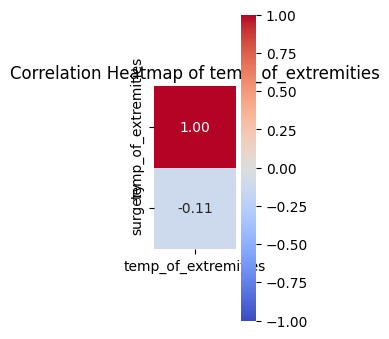

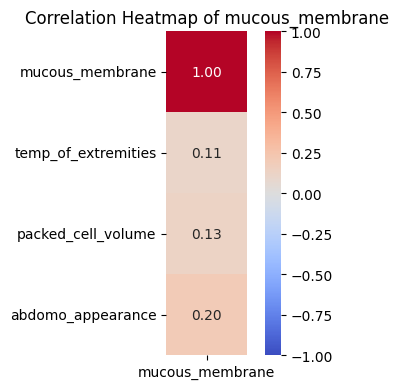

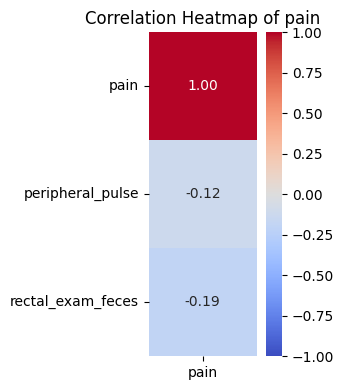

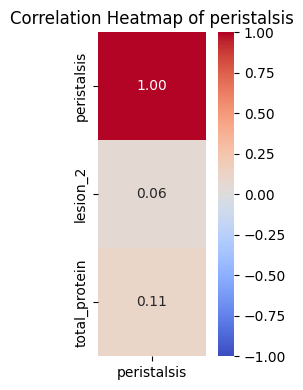

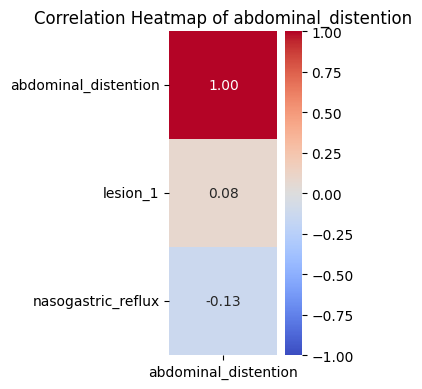

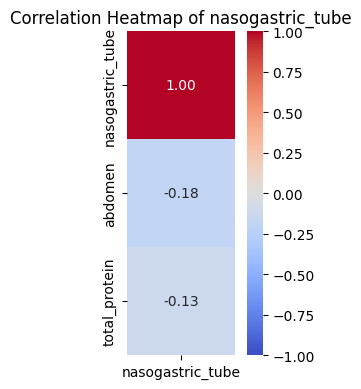

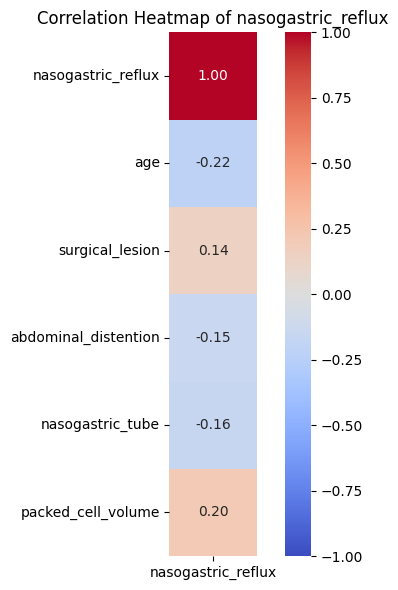

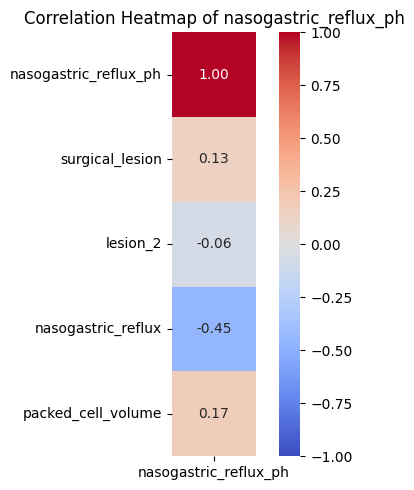

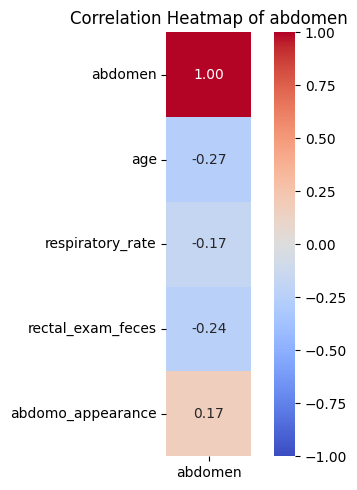

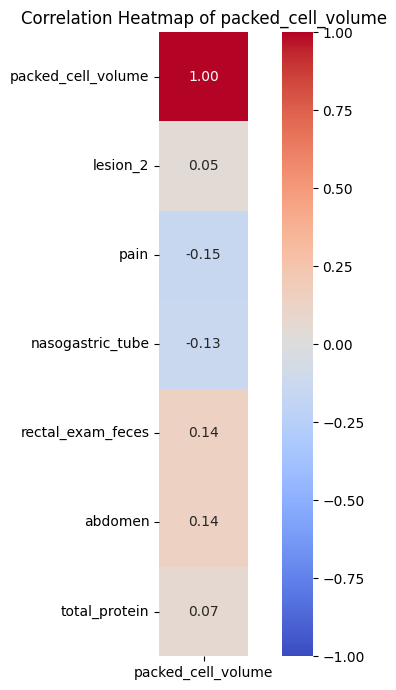

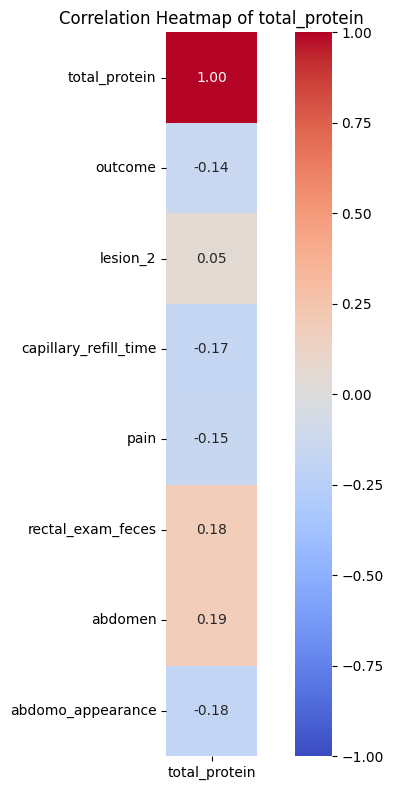

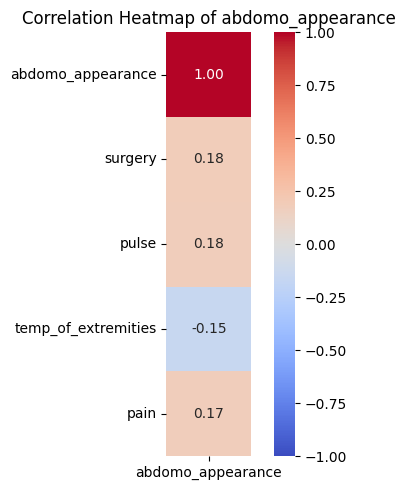

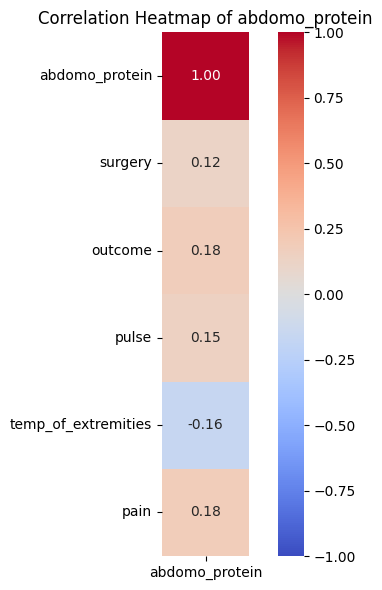

In [14]:
for mar_col in keys:
    _, _ = mv.missing_vs_all_correlation(df_num[mar_possible_df[mar_col]], mar_col, display_plot=True)


Most individual heatmaps express weak evidence for MAR in the missing columns. For example, `rectal_temp` has the following correlation values:
`rectal_exam_feces` (r = 0.25), `abdomo_appearance` (r = -0.25), `peristalsis` (r = 0.19), `mucous_membrane` (r = -0.19), `abdomen` (r = 0.18), and `temp_of_extremities` (r = 0.17). In other words, the missingness of `rectal_temp` is not strongly explained by any single variable. Instead, it is weakly related to gastrointestinal and circulation features, which makes it unlikely that `rectal_temp` is MCAR.

Another similar case is `abdomen`, where most of the absolute correlation values fall between 0.17 and 0.27. This indicates that `age`, `respiratory_rate`, `rectal_exam_feces`, and `abdomo_appearance` have only a weak relationship with the generation of missing values in `abdomen`.

However, one exception arises. The missingness of ``nasogastric_reflux_ph`` shows a moderate association with the observed values of ``nasogastric_reflux`` (r=−0.45). This suggests that whether the pH value is missing depends partly on the reflux category. This is  plausible, since the pH value is only meaningful when the reflux state is tested.

The associations of ``nasogastric_reflux_ph`` with ``packed_cell_volume`` (r=0.17) and ``surgical_lesion`` (r=0.13) are weak. Moreover, ``lesion_2`` (r=−0.06) shows almost no relationship. In essence, ``nasogastric_reflux_ph`` is unlikely to be MCAR, and is more close to have MAR mechanism that is mainly explained by the feature ``nasogastric_reflux``.

Nevertheless, the negative sign in r = −0.45 should be interpreted carefully, because ``nasogastric_reflux`` is categorical. 

### 11. Distribution of observed variables by ``nasogastric_reflux_ph`` missingness

In this section, the focus is on the missingness of `nasogastric_reflux_ph` and on identifying which `nasogastric_reflux` category contributes most to its missing values.


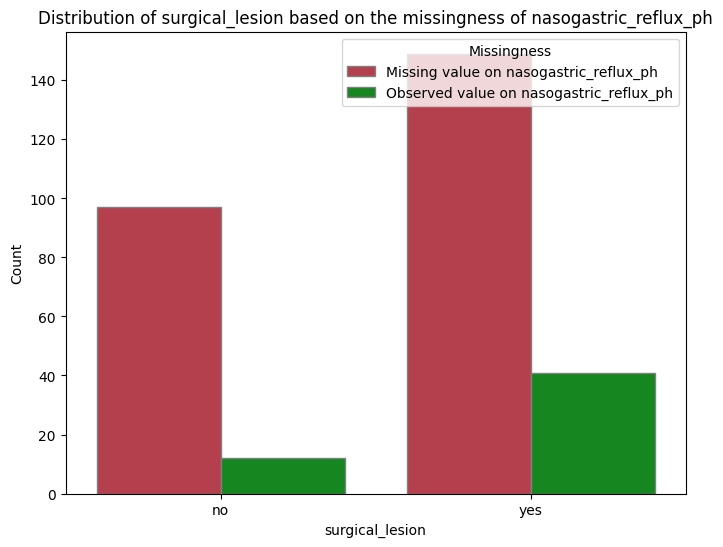

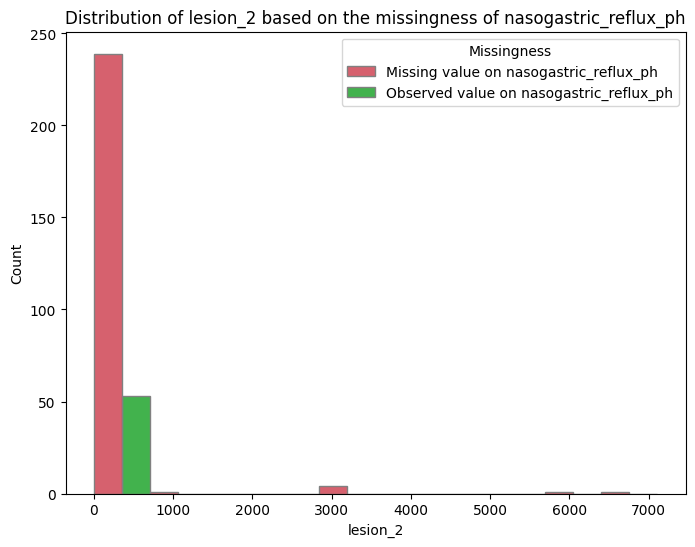

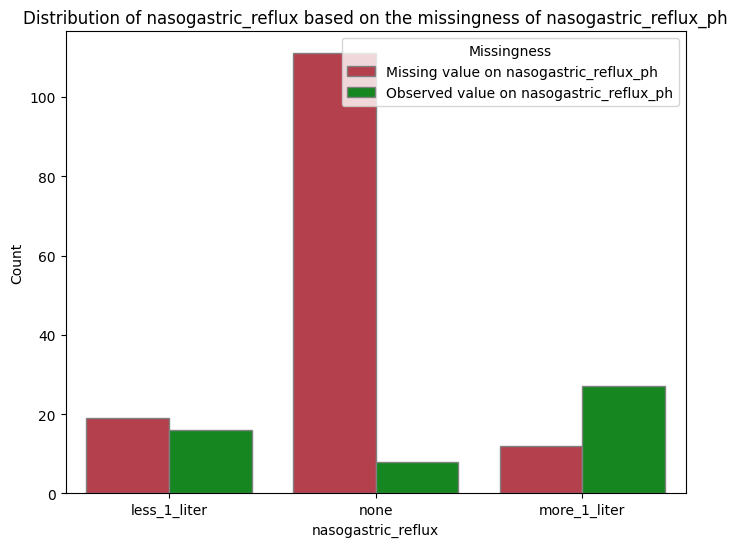

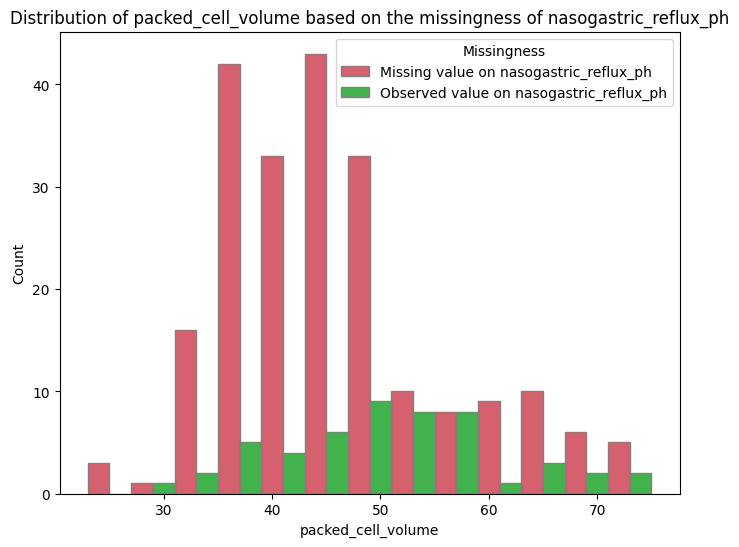

In [22]:
_ = mv.build_distribution_of_missingness(df[mar_possible_df["nasogastric_reflux_ph"]], "nasogastric_reflux_ph", display_plot=True)

The results exhibit that `surgical_lesion` and `lesion_2` have an uniform distribution for the `nasogastric_reflux_ph` missingness. For `packed_cell_volume`, there is a shift of distribution based on the missingness of `nasogastric_reflux_ph`, which was expected from the previous findings. It seems that the missingness increases for normal values of `packed_cell_volume`, which is the range between 30 to 50. This sugests that the reflux pH is not measured if the horse does not present a compromised circulation system and does not present dehydration symptoms. In the extreme levels of `packed_cell_volume`, there seems to exist a slight rise of missing values, which could represent that horses in severe health stages are examined in other variables, rather than the reflux pH.

However, it is important to discuss the prominent distribution of `nasogastric_reflux`. From observing its plot, if the horse does not showcase any reflux symptom, then most of the time `nasogastric_reflux_ph` is not measured. In the same trajectory, if the horse has less than 1 liter of reflux, then the clinicians may or may not measure its pH. The percentage of missing values quickly shift when the horse has an high amount of reflux, indicating a possible serious obstruction to the fluid passage from the rest of the intestine. As a consequene, pH is highly measured.

Ultimately, `nasogastric_reflux_ph` clearly shows a MAR missing-data mechanism, which is affected by `packed_cell_volume` and `nasogastric_reflux`.

### 12. Final conclusion

Generally, the dataset is unlikely to be purely MCAR, as missingness is tied to specific clinical procedures. In fact, the global MCAR test rejects MCAR, and the visual checks show structured missingness for `nasogastric_reflux_ph`.

The strongest conclusions are as follows:

- `nasogastric_reflux_ph`, `abdomo_protein`, and `abdomo_appearance` have the highest missing rates of the dataset, missing together at 22 rows.
- Several missing patterns involve features that have `nasogastric` or `abdom` on its name.
- `nasogastric_reflux_ph` missingness is affected by `packed_cell_volume` and `nasogastric_reflux`.

The patterns of other variables can be tested more deeply. For instances, the missingness of ``abdomen`` related to ``age`` and `respiratory_rate`, or the missingness of `abdomo_appearance` and its related observed features. Of course, some findings may lead to nowhere or be unreliable due to the size of the dataset.